В данном ноутбуке соберем ключевые продуктовые выводы на основе когортного анализа удержания клиентов и возрастной сегментации.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

Общий тренд удержания

In [4]:
retention = pd.read_csv("processed_files/retention_table.csv")

retention[[
    "cohort_month",
    "retention_upto_d7",
    "retention_upto_d30",
    "retention_upto_d90"
]].head(12)

,cohort_month,retention_upto_d7,retention_upto_d30,retention_upto_d90
0,2018-09,0.186896,0.450271,0.695119
1,2018-10,0.152801,0.380756,0.628108
2,2018-11,0.128030,0.312364,0.520990
3,2018-12,0.120608,0.266477,0.458474
4,2019-01,0.110475,0.237858,0.428977
5,2019-02,0.103601,0.218355,0.393901
6,2019-03,0.114565,0.243353,0.433799
7,2019-04,0.112842,0.239435,0.433145
8,2019-05,0.118614,0.251496,0.424648
9,2019-06,0.123180,0.257506,0.384196


По когортам наблюдается постепенное снижение удержания в районе 30-го и 90-го дня. Ранние когорты демонстрируют более высокую вероятность повторной покупки, тогда как более поздние когорты удерживаются слабее.

Линейный график среднего удержания по времени

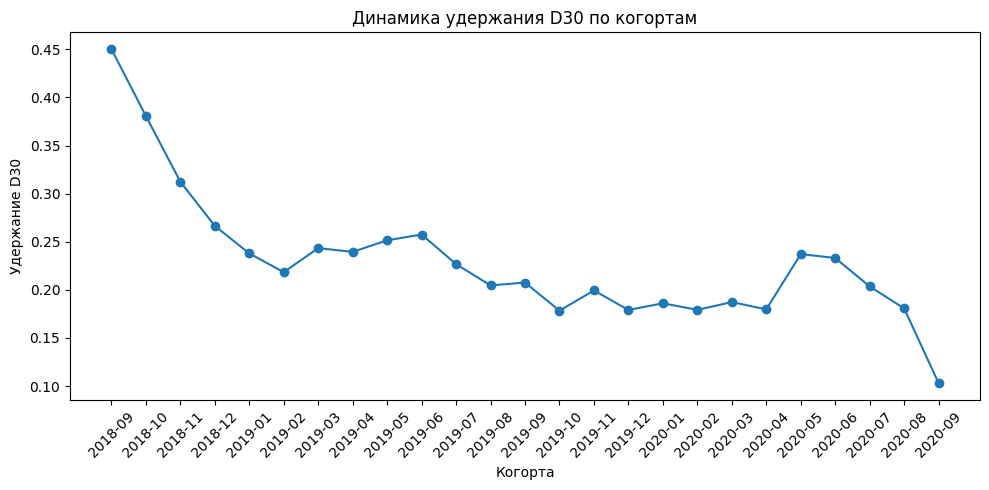

In [8]:
plt.figure(figsize = (10, 5))

plt.plot(
    retention["cohort_month"],
    retention["retention_upto_d30"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Динамика удержания D30 по когортам")
plt.ylabel("Удержание D30")
plt.xlabel("Когорта")

plt.tight_layout()
plt.show()

По мере продвижения по когортам наблюдается умеренное снижение удержания на 30-й день. Это может указывать на изменение качества привлечения клиентов или снижение доли повторных покупок.

Сезонные эффекты

In [6]:
retention["month"] = pd.to_datetime(retention["cohort_month"]).dt.month

season_summary = retention.groupby("month")[[
    "retention_upto_d30"
]].mean()

season_summary

,retention_upto_d30
month,
1,0.211927
2,0.198783
3,0.215313
4,0.209558
5,0.244334
6,0.245291
7,0.215121
8,0.192639
9,0.253611


Некоторые месяцы показывают более высокий retention, что может указывать на сезонный характер повторных покупок. Осенние когорты выглядят стабильнее, чем зимние и поздние летние.

Сезонный barplot

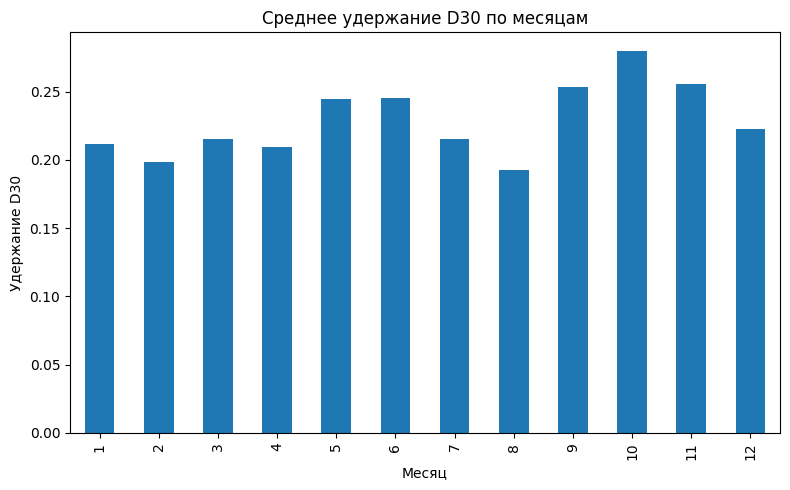

In [10]:
retention["month"] = pd.to_datetime(retention["cohort_month"]).dt.month

season_summary = retention.groupby("month")["retention_upto_d30"].mean()

plt.figure(figsize=(8, 5))

season_summary.plot(kind="bar")

plt.title("Среднее удержание D30 по месяцам")
plt.ylabel("Удержание D30")
plt.xlabel("Месяц")

plt.tight_layout()
plt.show()

Отдельные месяцы демонстрируют более высокий retention, что подтверждает влияние сезонных факторов на повторные покупки.

Различия между сегментами

In [7]:
summary = pd.read_csv("processed_files/age_summary.csv", index_col=0)
summary[['retention']]

,retention
age_group,
<25,0.269235
25-35,0.295030
35-50,0.273060
50+,0.283115


Возрастные группы показывают статистически значимые различия, но абсолютная разница между сегментами невелика. Возраст сам по себе не выглядит сильным драйвером удержания.

Возможные причины наблюдаемых различий:

1. Fast fashion приводит к разовым покупкам.
2. Клиенты могут приходить под сезонные коллекции и не возвращаться быстро.
3. Снижение удержания у поздних когорт может отражать изменение структуры спроса.
4. Промо-активности могут приводить к возрастанию количества первых заказов без формирования лояльности к компании.